# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [2]:
# untuk plot Q-Q
import scipy.stats as stats

In [4]:
df_california = pd.read_csv('california_dataset.csv')

In [3]:
from sklearn.model_selection import train_test_split
# splitting terlebih dahulu


#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

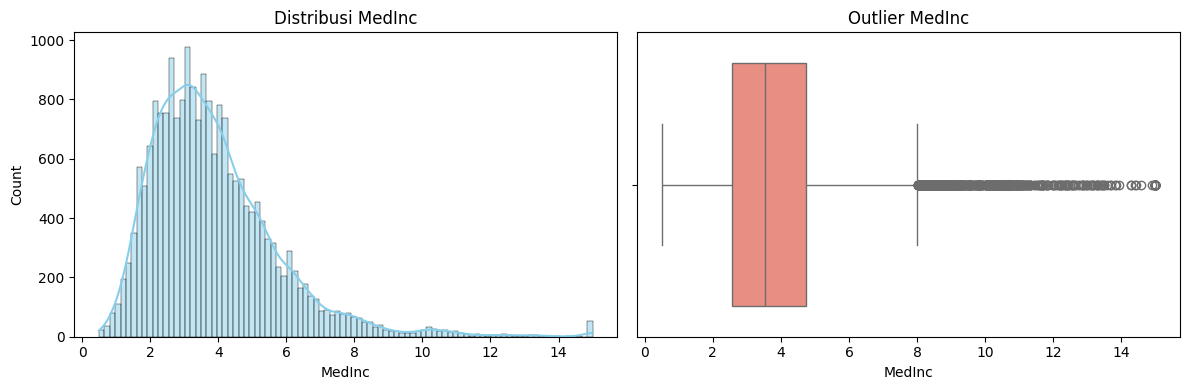

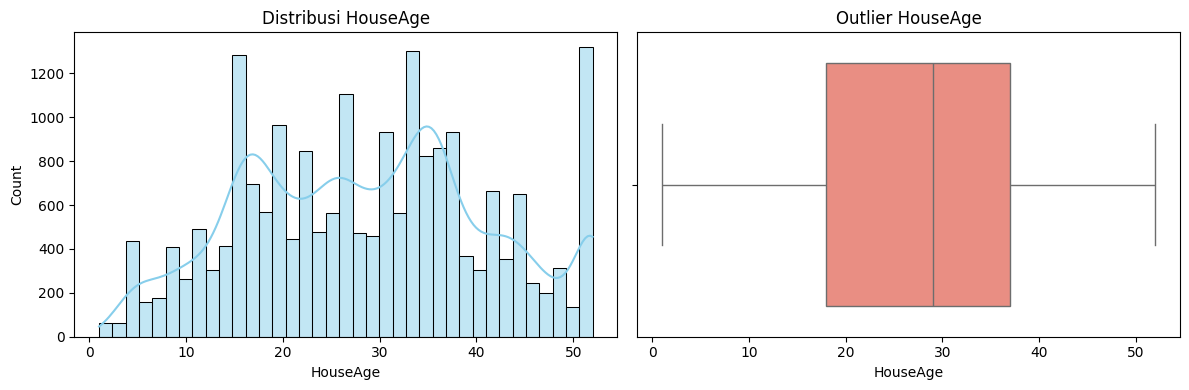

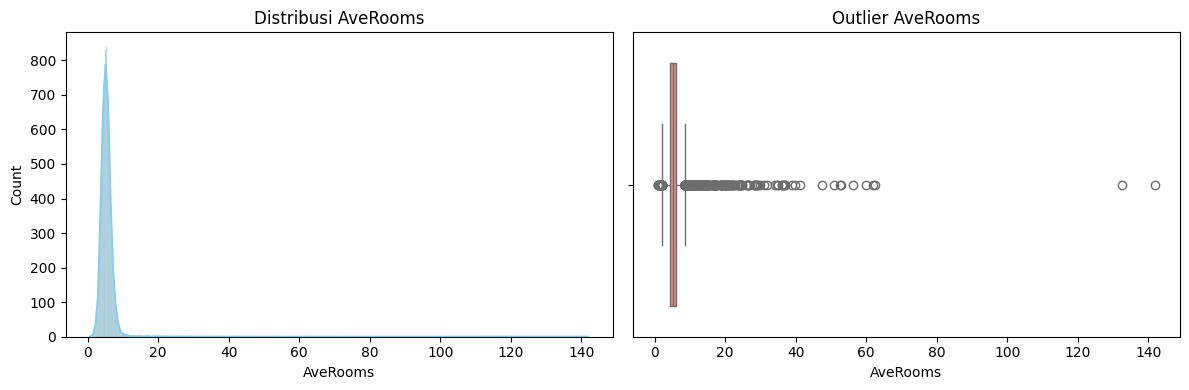

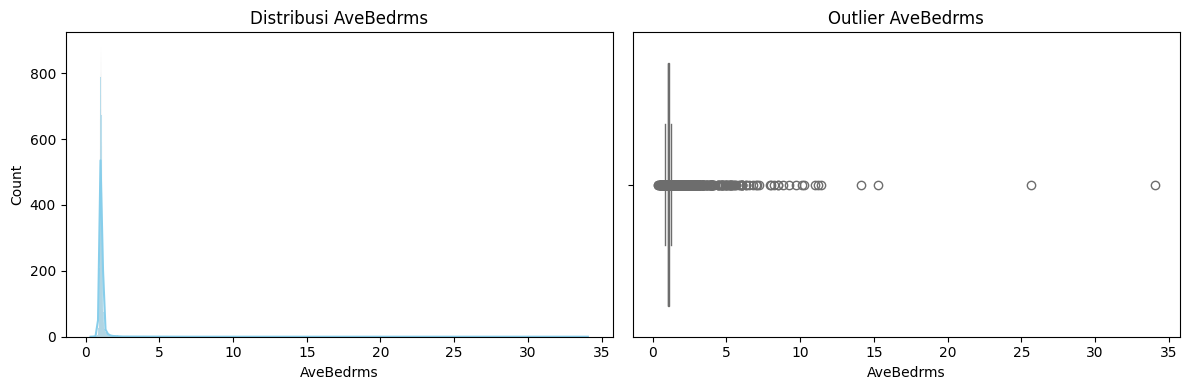

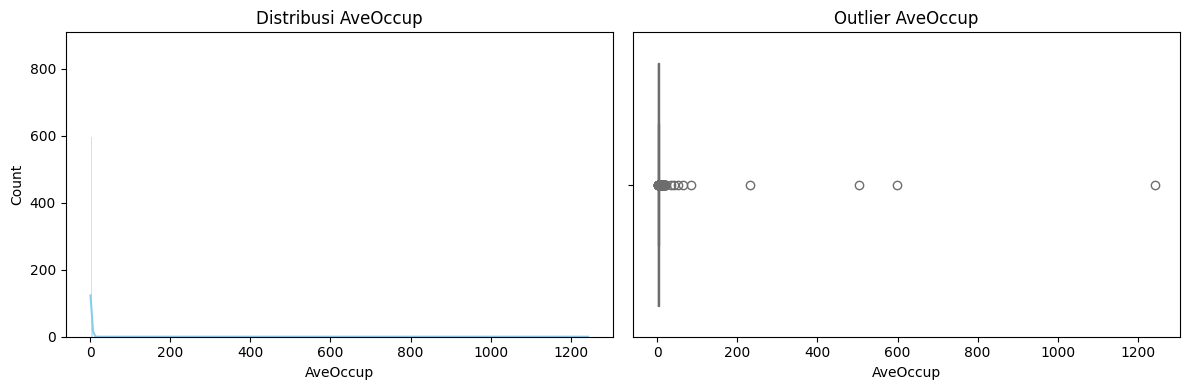

In [5]:
# Load dataset terlebih dahulu
df_california = pd.read_csv('california_dataset.csv')

# Daftar kolom yang ingin dicek
kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

# Looping untuk melihat plot distribusi dan outlier
for col in kolom_kolom:
    plt.figure(figsize=(12, 4))
    
    # Subplot 1: Histogram (Distribusi)
    plt.subplot(1, 2, 1)
    sns.histplot(df_california[col], kde=True, color='skyblue')
    plt.title(f'Distribusi {col}')
    
    # Subplot 2: Boxplot (Outlier)
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_california[col], color='salmon')
    plt.title(f'Outlier {col}')
    
    plt.tight_layout()
    plt.show()

### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

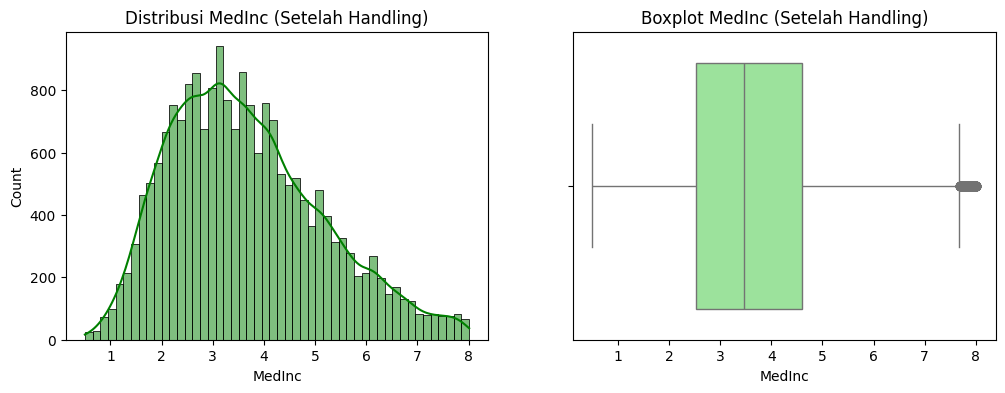

Jumlah data sebelum: 20640
Jumlah data setelah: 19959


In [6]:
# 1. Pilih 1 kolom (contoh: MedInc)
target_col = 'MedInc'

# Hitung Q1, Q3, dan IQR
Q1 = df_california[target_col].quantile(0.25)
Q3 = df_california[target_col].quantile(0.75)
IQR = Q3 - Q1

# Tentukan batas bawah dan batas atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter data (Handling Outlier)
df_filtered = df_california[(df_california[target_col] >= lower_bound) & (df_california[target_col] <= upper_bound)]

# 2. Cek distribusinya kembali
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df_filtered[target_col], kde=True, color='green')
plt.title(f'Distribusi {target_col} (Setelah Handling)')

plt.subplot(1, 2, 2)
sns.boxplot(x=df_filtered[target_col], color='lightgreen')
plt.title(f'Boxplot {target_col} (Setelah Handling)')

plt.show()

print(f"Jumlah data sebelum: {len(df_california)}")
print(f"Jumlah data setelah: {len(df_filtered)}")

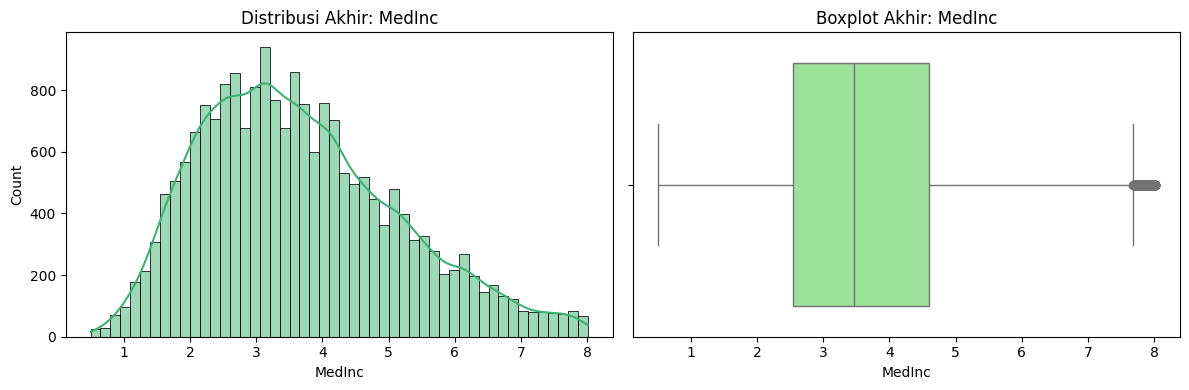

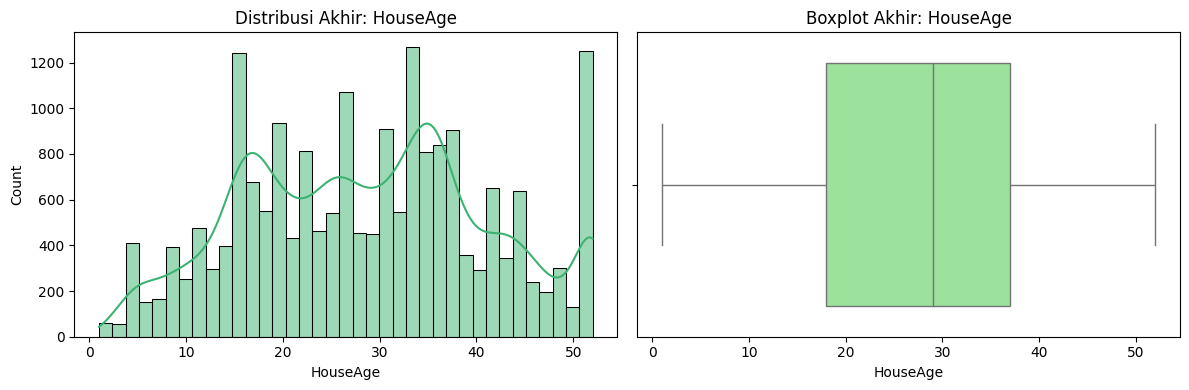

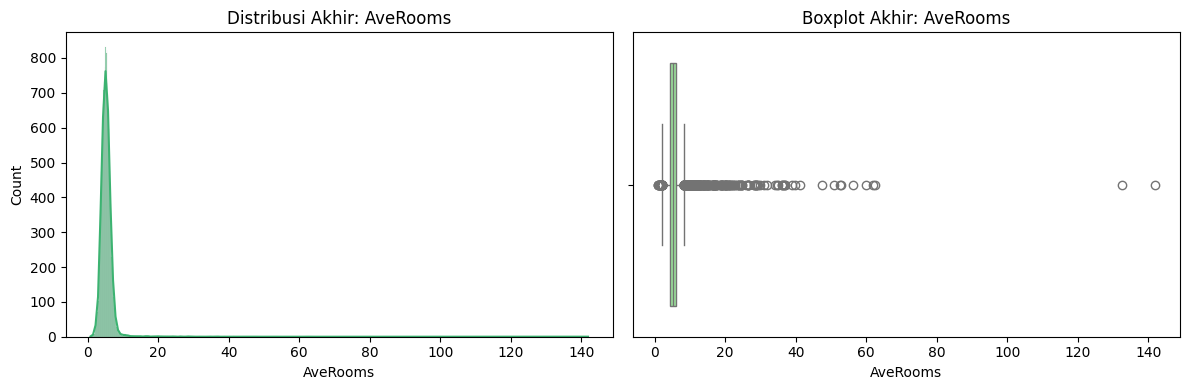

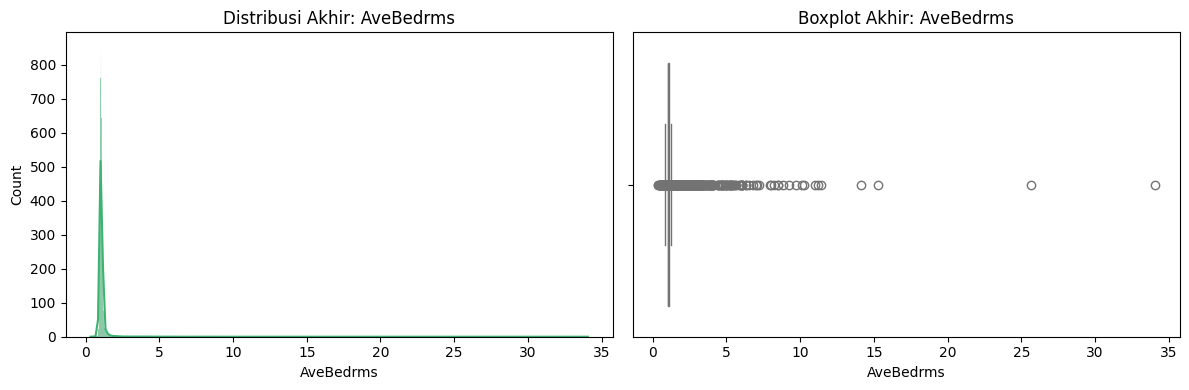

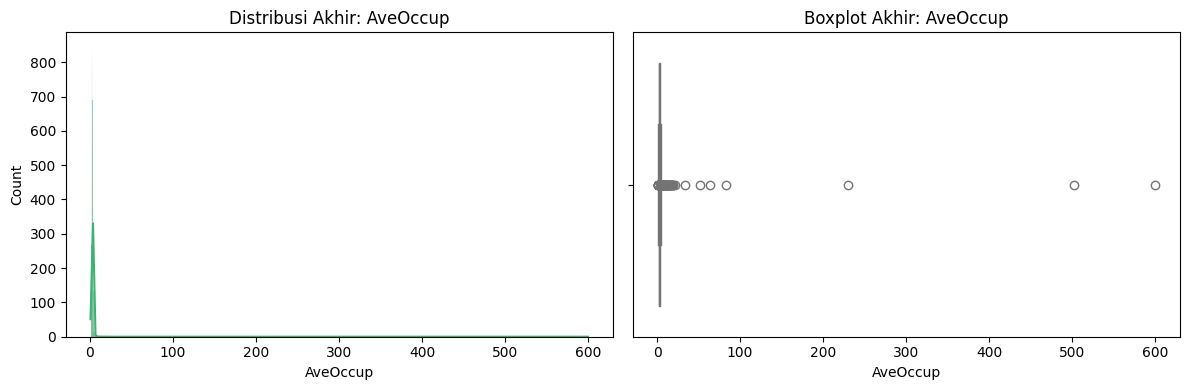

In [7]:
# Daftar kolom yang ingin dicek kembali distribusinya
kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

# Melakukan loop untuk mengecek distribusi tiap kolom (setelah handling outlier)
for col in kolom_kolom:
    plt.figure(figsize=(12, 4))
    
    # Plot Distribusi (Histogram + KDE)
    plt.subplot(1, 2, 1)
    sns.histplot(df_filtered[col], kde=True, color='mediumseagreen')
    plt.title(f'Distribusi Akhir: {col}')
    
    # Plot Boxplot (Cek sisa outlier)
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_filtered[col], color='lightgreen')
    plt.title(f'Boxplot Akhir: {col}')
    
    plt.tight_layout()
    plt.show()

# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [9]:
df_company = pd.read_csv('company.csv')

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [10]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [11]:
# Load dataset company
df_company = pd.read_csv('company.csv')

# 1. Cek persentase missing value pada kolom Headquarters
missing_count = df_company['Headquarters'].isnull().sum()
percentage_missing = (missing_count / len(df_company)) * 100

print(f"Jumlah Missing Value di Headquarters: {missing_count}")
print(f"Persentase Missing Value: {percentage_missing:.2f}%")

# 2. Apakah di drop atau tidak? (Syarat drop jika > 20%)
if percentage_missing > 20:
    print("Keputusan: Kolom di-DROP karena missing value > 20%")
    # df_company.drop(columns=['Headquarters'], inplace=True)
else:
    print("Keputusan: Kolom TIDAK di-drop, lakukan handling (Imputasi)")
    
    # 3. Handling dengan Modus (karena Headquarters adalah data kategorikal/teks)
    # Kita ambil index [0] karena mode() mengembalikan Series
    modus_hq = df_company['Headquarters'].mode()[0]
    df_company['Headquarters'] = df_company['Headquarters'].fillna(modus_hq)
    
    print(f"Nilai Modus yang digunakan untuk mengisi: {modus_hq}")
    print(f"Jumlah missing value setelah handling: {df_company['Headquarters'].isnull().sum()}")

Jumlah Missing Value di Headquarters: 0
Persentase Missing Value: 0.00%
Keputusan: Kolom TIDAK di-drop, lakukan handling (Imputasi)
Nilai Modus yang digunakan untuk mengisi: New York, NY
Jumlah missing value setelah handling: 0


# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [13]:
df_churn = pd.read_csv('TelcoCustomerChurn.csv')

In [14]:
from sklearn.model_selection import train_test_split

# 1. Tentukan Fitur (X) dan Target (y)
# Asumsi: Kolom 'Churn' adalah target yang ingin diprediksi
X = df_churn.drop('Churn', axis=1)
y = df_churn['Churn']

# 2. Lakukan Splitting
# test_size=0.2 artinya 20% data untuk testing, 80% untuk training
# random_state=42 agar hasil split tetap sama setiap kali dijalankan (reproducible)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Cek ukuran data hasil split
print(f"Jumlah data training (X_train): {X_train.shape[0]}")
print(f"Jumlah data testing (X_test): {X_test.shape[0]}")


Jumlah data training (X_train): 5634
Jumlah data testing (X_test): 1409


## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [15]:
# Daftar kolom yang dipilih
kolom_target = ['StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection', 
                'OnlineBackup', 'OnlineSecurity', 'MultipleLines']

# Mengganti nilai 'No internet service' (dan 'No phone service') menjadi 'No'
df_churn[kolom_target] = df_churn[kolom_target].replace({'No internet service': 'No', 
                                                         'No phone service': 'No'})

In [16]:
# Validasi hasil perubahan untuk setiap kolom
for col in kolom_target:
    print(f"Value counts untuk {col}:")
    print(df_churn[col].value_counts())
    print("-" * 30)

Value counts untuk StreamingMovies:
StreamingMovies
No     4311
Yes    2732
Name: count, dtype: int64
------------------------------
Value counts untuk StreamingTV:
StreamingTV
No     4336
Yes    2707
Name: count, dtype: int64
------------------------------
Value counts untuk TechSupport:
TechSupport
No     4999
Yes    2044
Name: count, dtype: int64
------------------------------
Value counts untuk DeviceProtection:
DeviceProtection
No     4621
Yes    2422
Name: count, dtype: int64
------------------------------
Value counts untuk OnlineBackup:
OnlineBackup
No     4614
Yes    2429
Name: count, dtype: int64
------------------------------
Value counts untuk OnlineSecurity:
OnlineSecurity
No     5024
Yes    2019
Name: count, dtype: int64
------------------------------
Value counts untuk MultipleLines:
MultipleLines
No     4072
Yes    2971
Name: count, dtype: int64
------------------------------


In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Melakukan looping Label Encoder untuk setiap kolom di daftar
for col in kolom_target:
    df_churn[col] = le.fit_transform(df_churn[col])

# Menampilkan hasil transformasi (0 biasanya 'No', 1 biasanya 'Yes')
print("Proses Label Encoding Selesai!")

Proses Label Encoding Selesai!


In [18]:
# Cek 5 data teratas untuk memastikan kolom sudah menjadi numerik
df_churn[kolom_target].head()

,StreamingMovies,StreamingTV,TechSupport,DeviceProtection,OnlineBackup,OnlineSecurity,MultipleLines
0,0,0,0,0,1,0,0
1,0,0,0,1,0,1,0
2,0,0,0,0,1,1,0
3,0,0,1,1,0,1,0
4,0,0,0,0,0,0,0


## Selesai :)